# **FULL UNSUPERVISED LEARNING PROJECT**
# **STUDENT BEHAVIOR SEGMENTATION USING K-MEANS CLUSTERING**

**STEP 1: IMPORT LIBRARIES**

In [ ]:
# =========================================================
# FULL UNSUPERVISED LEARNING PROJECT
# STUDENT BEHAVIOR SEGMENTATION USING K-MEANS CLUSTERING
# =========================================================

# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Optional: to ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
#drive.mount('/content/drive')


**Step 2: LOAD DATASET**

In [ ]:
# 2. LOAD DATASET
# -------------------------------
df = pd.read_csv("/content/sample_data/student_dropout_behavior_dataset.csv")

print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

FIRST 5 ROWS OF THE DATASET
   student_id              name  age  gender  quiz1_marks  quiz2_marks  \
0           1  Kristina Vaughan   19    Male          8.0          5.7   
1           2    Rodney Daniels   21    Male         10.0          7.9   
2           3         Jose Nash   19  Female          7.5          1.2   
3           4     Nicole Martin   21    Male          5.2          2.5   
4           5      Shelby Smith   21  Female          5.9          6.3   

   quiz3_marks  total_assignments  assignments_submitted  midterm_marks  \
0          7.4                  5                    NaN           30.0   
1          4.1                  5                    NaN           25.4   
2          0.3                  5                    NaN           14.4   
3          9.9                  5                    NaN           17.7   
4          2.0                  5                    NaN           23.8   

   final_marks  previous_gpa  total_lectures  lectures_attended  \
0        

**STEP 3: DATA CLEANING**

In [ ]:
 #-------------------------------
# 3. DATA CLEANING
# -------------------------------
# Drop unnecessary columns if they exist
drop_cols = ["student_id", "name", "assignments_submitted"]
existing_drop_cols = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=existing_drop_cols)

# Encode gender if present
if "gender" in df.columns:
    df["gender"] = df["gender"].map({"Male": 0, "Female": 1})


**STEP 4: FEATURE ENGINEERING**

In [ ]:
# -------------------------------
# 4. FEATURE ENGINEERING
# -------------------------------
# Create attendance rates
df["lecture_attendance_rate"] = df["lectures_attended"] / df["total_lectures"]
df["lab_attendance_rate"] = df["labs_attended"] / df["total_lab_sessions"]

# Create average quiz marks
df["average_quiz_marks"] = (
    df["quiz1_marks"] + df["quiz2_marks"] + df["quiz3_marks"]
) / 3

# Create overall academic score
df["overall_academic_score"] = (
    df["average_quiz_marks"] + df["midterm_marks"] + df["final_marks"]
) / 3

print("\n" + "=" * 60)
print("DATA AFTER FEATURE ENGINEERING")
print("=" * 60)
print(df.head())


DATA AFTER FEATURE ENGINEERING
   age  gender  quiz1_marks  quiz2_marks  quiz3_marks  total_assignments  \
0   19       0          8.0          5.7          7.4                  5   
1   21       0         10.0          7.9          4.1                  5   
2   19       1          7.5          1.2          0.3                  5   
3   21       0          5.2          2.5          9.9                  5   
4   21       1          5.9          6.3          2.0                  5   

   midterm_marks  final_marks  previous_gpa  total_lectures  \
0           30.0         36.5          2.57              12   
1           25.4         33.0          2.40              12   
2           14.4         24.8          2.99              12   
3           17.7         41.0          1.68              12   
4           23.8         31.0          2.53              12   

   lectures_attended  total_lab_sessions  labs_attended  \
0                  4                   6              1   
1             

**STEP 5: SELECT FEATURES**

In [ ]:
# -------------------------------
# 5. SELECT FEATURES
# -------------------------------
features = [
    "age",
    "gender",
    "average_quiz_marks",
    "midterm_marks",
    "final_marks",
    "previous_gpa",
    "lecture_attendance_rate",
    "lab_attendance_rate",
    "overall_academic_score"
]

X = df[features]

print("\n" + "=" * 60)
print("SELECTED FEATURES FOR CLUSTERING")
print("=" * 60)
print(X.head())



SELECTED FEATURES FOR CLUSTERING
   age  gender  average_quiz_marks  midterm_marks  final_marks  previous_gpa  \
0   19       0            7.033333           30.0         36.5          2.57   
1   21       0            7.333333           25.4         33.0          2.40   
2   19       1            3.000000           14.4         24.8          2.99   
3   21       0            5.866667           17.7         41.0          1.68   
4   21       1            4.733333           23.8         31.0          2.53   

   lecture_attendance_rate  lab_attendance_rate  overall_academic_score  
0                 0.333333             0.166667               24.511111  
1                 0.083333             0.833333               21.911111  
2                 0.000000             0.000000               14.066667  
3                 0.750000             0.000000               21.522222  
4                 0.583333             0.666667               19.844444  


 **STEP 6: SCALE DATA**

In [ ]:
# -------------------------------
# 6. SCALE DATA
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**STEP 7: ELBOW METHOD**

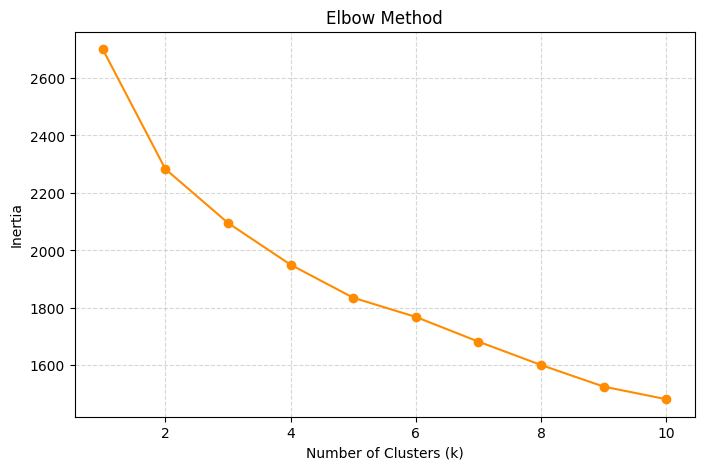

In [ ]:
# -------------------------------
# 7. ELBOW METHOD
# -------------------------------
inertia = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', color='darkorange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**STEP 8: SILHOUETTE SCORE**

In [ ]:
# -------------------------------
# 8. SILHOUETTE SCORE
# -------------------------------
print("\n" + "=" * 60)
print("SILHOUETTE SCORES")
print("=" * 60)

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}: {score:.3f}")



SILHOUETTE SCORES
k = 2: 0.143
k = 3: 0.117
k = 4: 0.117
k = 5: 0.115
k = 6: 0.116


**STEP 9: TRAIN FINAL K-MEANS MODEL**

In [ ]:
# -------------------------------
# 9. TRAIN FINAL K-MEANS MODEL
# -------------------------------
# Adjust n_clusters based on elbow and silhouette results
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

**STEP 10: CLUSTER SUMMARY**

In [ ]:
# -------------------------------
# 10. CLUSTER SUMMARY
# -------------------------------
cluster_summary = df.groupby("Cluster")[features].mean()

print("\n" + "=" * 60)
print("CLUSTER MEANS")
print("=" * 60)
print(cluster_summary)

print("\n" + "=" * 60)
print("CLUSTER SIZES")
print("=" * 60)
print(df["Cluster"].value_counts().sort_index())



CLUSTER MEANS
               age    gender  average_quiz_marks  midterm_marks  final_marks  \
Cluster                                                                        
0        21.568421  0.547368            6.593333      12.065263    40.670526   
1        21.789062  0.609375            6.300781      25.551562    44.033594   
2        21.129870  0.324675            5.534632      20.440260    22.240260   

         previous_gpa  lecture_attendance_rate  lab_attendance_rate  \
Cluster                                                               
0            2.842947                 0.426316             0.640351   
1            2.874766                 0.522786             0.496094   
2            2.646234                 0.557359             0.404762   

         overall_academic_score  
Cluster                          
0                     19.776374  
1                     25.295313  
2                     16.071717  

CLUSTER SIZES
Cluster
0     95
1    128
2     77
Name: co

**STEP 11: ASSIGN CLUSTER NAMES**

In [ ]:
# -------------------------------
# 11. ASSIGN CLUSTER NAMES
# -------------------------------
# Update these names if the cluster order changes in your output
cluster_names = {
    0: "Average Students",
    1: "High Performing & Engaged",
    2: "At-Risk Students"
}

df["Cluster_Type"] = df["Cluster"].map(cluster_names)

print("\n" + "=" * 60)
print("CLUSTER TYPE COUNTS")
print("=" * 60)
print(df["Cluster_Type"].value_counts())



CLUSTER TYPE COUNTS
Cluster_Type
High Performing & Engaged    128
Average Students              95
At-Risk Students              77
Name: count, dtype: int64


**STEP 12: VISUALIZATION 1**

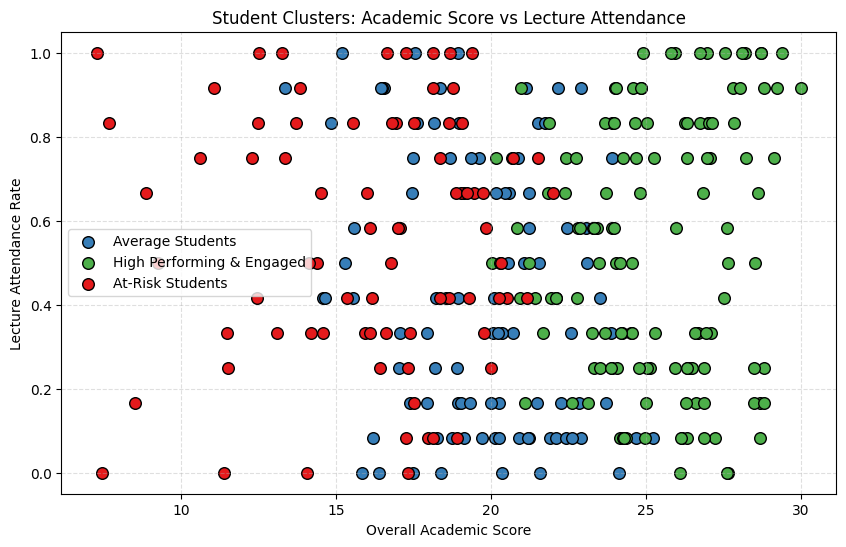

In [ ]:
# -------------------------------
# 12. VISUALIZATION 1
# OVERALL ACADEMIC SCORE VS LECTURE ATTENDANCE RATE
# -------------------------------
colors = ['#377eb8', '#4daf4a', '#e41a1c']

plt.figure(figsize=(10, 6))
for i in range(optimal_k):
    cluster_data = df[df["Cluster"] == i]
    plt.scatter(
        cluster_data["overall_academic_score"],
        cluster_data["lecture_attendance_rate"],
        color=colors[i],
        s=70,
        edgecolor='black',
        label=cluster_names[i]
    )

plt.xlabel("Overall Academic Score")
plt.ylabel("Lecture Attendance Rate")
plt.title("Student Clusters: Academic Score vs Lecture Attendance")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

**STEP 13: VISUALIZATION**

In [ ]:
# -------------------------------
# 13. VISUALIZATION 2
# PREVIOUS GPA VS FINAL MARKS
# -------------------------------
plt.figure(figsize=(10, 6))
for i in range(optimal_k):
    cluster_data = df[df["Cluster"] == i]
    plt.scatter(
        cluster_data["previous_gpa"],
        cluster_data["final_marks"],
        color=colors[i],
        s=70,
        edgecolor='black',
        label=cluster_names[i]
    )

plt.xlabel("Previous GPA")
plt.ylabel("Final Marks")
plt.title("Student Clusters: Previous GPA vs Final Marks")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


**STEP 14: SAVE CLUSTERED DATASET**

In [ ]:
# -------------------------------
# 14. SAVE CLUSTERED DATASET
# -------------------------------
df.to_csv("student_clustered_output.csv", index=False)
print("\nClustered dataset saved as 'student_clustered_output.csv'")

**STEP 15: SAVE MODEL AND SCALER**

In [ ]:
# -------------------------------
# 15. SAVE MODEL AND SCALER
# -------------------------------
joblib.dump(kmeans, "student_kmeans_model.pkl")
joblib.dump(scaler, "student_scaler.pkl")

print("Model saved as 'student_kmeans_model.pkl'")
print("Scaler saved as 'student_scaler.pkl'")

**STEP 16: LOAD MODEL AND TEST ON NEW DATA**

In [ ]:
# -------------------------------
# 16. LOAD MODEL AND TEST ON NEW DATA
# -------------------------------
loaded_model = joblib.load("student_kmeans_model.pkl")
loaded_scaler = joblib.load("student_scaler.pkl")

new_student = pd.DataFrame([{
    "age": 22,
    "gender": 0,  # Male=0, Female=1
    "average_quiz_marks": 68,
    "midterm_marks": 65,
    "final_marks": 70,
    "previous_gpa": 3.1,
    "lecture_attendance_rate": 0.80,
    "lab_attendance_rate": 0.75,
    "overall_academic_score": (68 + 65 + 70) / 3
}])

new_student_scaled = loaded_scaler.transform(new_student)
predicted_cluster = loaded_model.predict(new_student_scaled)[0]

print("\n" + "=" * 60)
print("PREDICTION FOR NEW STUDENT")
print("=" * 60)
print("Predicted Cluster Number:", predicted_cluster)
print("Predicted Cluster Type:", cluster_names[predicted_cluster])


PREDICTION FOR NEW STUDENT
Predicted Cluster Number: 1
Predicted Cluster Type: High Performing & Engaged


**STEP 17: HIERARCHICAL CLUSTERING COMPARISON**

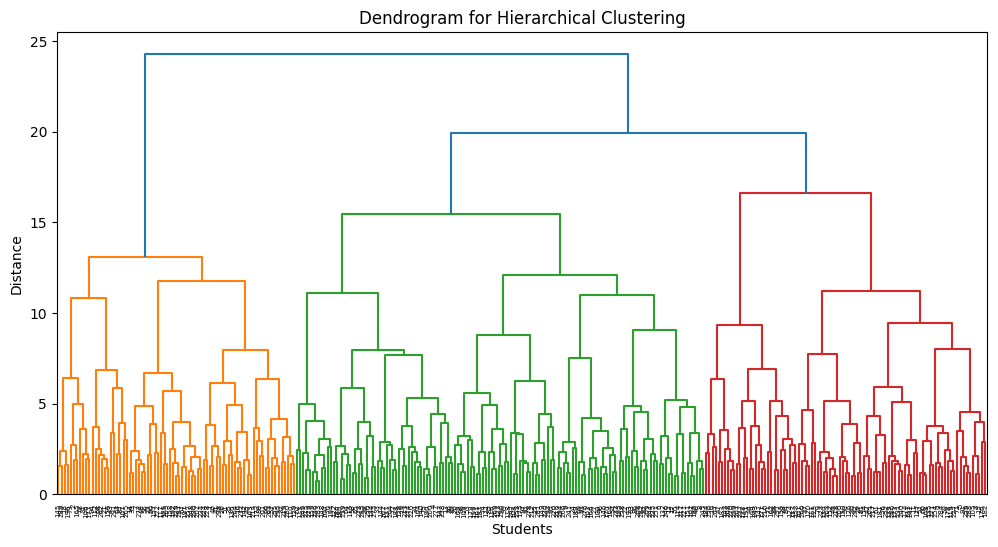


HIERARCHICAL CLUSTERING MEANS
                  age    gender  average_quiz_marks  midterm_marks  \
HC_Cluster                                                           
0           21.835165  0.142857            6.349084      15.974725   
1           20.948052  0.233766            5.583550      20.775325   
2           21.704545  0.939394            6.449495      22.252273   

            final_marks  previous_gpa  lecture_attendance_rate  \
HC_Cluster                                                       
0             42.378022      2.543626                 0.470696   
1             24.606494      2.957662                 0.505411   
2             41.374242      2.898485                 0.519571   

            lab_attendance_rate  overall_academic_score  
HC_Cluster                                               
0                      0.648352               21.567277  
1                      0.367965               16.988456  
2                      0.516414               23.358670

In [ ]:
# -------------------------------
# 17. HIERARCHICAL CLUSTERING COMPARISON
# -------------------------------
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

hc = AgglomerativeClustering(n_clusters=3)
df["HC_Cluster"] = hc.fit_predict(X_scaled)

print("\n" + "=" * 60)
print("HIERARCHICAL CLUSTERING MEANS")
print("=" * 60)
print(df.groupby("HC_Cluster")[features].mean())

print("\n" + "=" * 60)
print("HIERARCHICAL CLUSTERING SIZES")
print("=" * 60)
print(df["HC_Cluster"].value_counts().sort_index())

**STEP 18: PCA VISUALIZATION**

In [ ]:
# -------------------------------
# 18. PCA VISUALIZATION
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
for i in range(optimal_k):
    plt.scatter(
        X_pca[df["Cluster"] == i, 0],
        X_pca[df["Cluster"] == i, 1],
        color=colors[i],
        s=70,
        edgecolor='black',
        label=cluster_names[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Student Clusters")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


**STEP 19: FINAL MESSAGE**

In [ ]:
# -------------------------------
# 19. FINAL MESSAGE
# -------------------------------
print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)
print("Outputs generated:")
print("1. Elbow Method plot")
print("2. Silhouette Scores")
print("3. K-Means Cluster Summary")
print("4. Cluster Visualizations")
print("5. Saved clustered dataset")
print("6. Saved model and scaler")
print("7. New student prediction")
print("8. Hierarchical clustering comparison")
print("9. PCA visualization")


PROJECT COMPLETED SUCCESSFULLY
Outputs generated:
1. Elbow Method plot
2. Silhouette Scores
3. K-Means Cluster Summary
4. Cluster Visualizations
5. Saved clustered dataset
6. Saved model and scaler
7. New student prediction
8. Hierarchical clustering comparison
9. PCA visualization
